This trading strategy is based off of taking long and short trades using the MACD 12 and 26 EMA's as criteria



In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
#Downloading 10-years of google ticker data to a pandas dataframe

goog = yf.Ticker('GOOG')
print(goog)

from datetime import datetime
today = datetime.today()

google_hist = goog.history(start = "2016-01-01", end = today, interval = '1d')

yfinance.Ticker object <GOOG>
                                 Open        High         Low       Close  \
Date                                                                        
2016-01-04 00:00:00-05:00   36.847485   36.900051   36.265165   36.789955   
2016-01-05 00:00:00-05:00   37.018574   37.293814   36.631254   36.826653   
2016-01-06 00:00:00-05:00   36.202773   37.054779   36.149212   36.878227   
2016-01-07 00:00:00-05:00   36.218146   36.624311   35.660226   36.023743   
2016-01-08 00:00:00-05:00   36.274680   36.362956   35.359695   35.432594   
...                               ...         ...         ...         ...   
2026-05-13 00:00:00-04:00  381.904999  399.929993  381.579987  399.040009   
2026-05-14 00:00:00-04:00  393.790009  399.104004  392.727997  397.170013   
2026-05-15 00:00:00-04:00  393.214996  395.880005  389.760010  393.320007   
2026-05-18 00:00:00-04:00  392.125000  404.470001  390.899994  393.109985   
2026-05-19 00:00:00-04:00  393.299988  393.363

In [ ]:
#Making EMA's
#from scratch, likely a better way to do this

#For the EMA's you need SMA's
#12 and 26 day sma
mas = pd.DataFrame({'SMA12':google_hist['Close'].rolling(12).mean(), 
                     'SMA26':google_hist['Close'].rolling(26).mean()})


#Assigining the starting values for both ema's
mas['EMA12'] = None
mas['EMA26'] = None

mas.loc[mas.index[11],'EMA12']= mas['SMA12'].iloc[11]
mas.loc[mas.index[25],'EMA26']= mas['SMA26'].iloc[25]

#joining the close data for calculations

mas["Close"] = (google_hist["Close"])

#Assigining variables for the function that calculates the EMA
mult12 = 2/13
mult26 = 2/27

# Not familiar enough with the syntax so used an AI to get the syntax for pulling the data, calculation was correct nontheless
for i in range(12, len(mas)):
    mas.iloc[i, mas.columns.get_loc('EMA12')] = (
        mas['Close'].iloc[i] * mult12 +
        mas['EMA12'].iloc[i-1] * (1 - mult12)
    )

for i in range(26, len(mas)):
    mas.iloc[i, mas.columns.get_loc('EMA26')] = (
        mas['Close'].iloc[i] * mult26 +
        mas['EMA26'].iloc[i-1] * (1 - mult26)
    )

print(mas)

# In no way an efficent way of making the EMA's did it just for practise, there is a built-in function to calculate the EMA



                                SMA12       SMA26       EMA12       EMA26  \
Date                                                                        
2016-01-04 00:00:00-05:00         NaN         NaN        None        None   
2016-01-05 00:00:00-05:00         NaN         NaN        None        None   
2016-01-06 00:00:00-05:00         NaN         NaN        None        None   
2016-01-07 00:00:00-05:00         NaN         NaN        None        None   
2016-01-08 00:00:00-05:00         NaN         NaN        None        None   
...                               ...         ...         ...         ...   
2026-05-13 00:00:00-04:00  381.750000  354.478844  380.271035    359.7675   
2026-05-14 00:00:00-04:00  385.889168  357.649230  382.870878  362.538056   
2026-05-15 00:00:00-04:00  389.723335  360.608846  384.478436  364.818201   
2026-05-18 00:00:00-04:00  390.654167  363.585383  385.806367  366.913888   
2026-05-19 00:00:00-04:00  390.794167  366.111922  385.666925  368.246193   

In [92]:
# Now with built in functions:

google_hist["EMA12"] = google_hist["Close"].ewm(span = 12, adjust = False).mean()
google_hist["EMA26"] = google_hist["Close"].ewm(span = 26, adjust = False).mean()

#Right now the EMA's have values even before they should have and are therefore inaccurate at those points
#To counteract this we'll set the previous values to NaN
google_hist.loc[google_hist.index[:11], 'EMA12'] = None
google_hist.loc[google_hist.index[:25], 'EMA26'] = None

print(google_hist[['EMA12','EMA26']])

                                EMA12       EMA26
Date                                             
2016-01-04 00:00:00-05:00         NaN         NaN
2016-01-05 00:00:00-05:00         NaN         NaN
2016-01-06 00:00:00-05:00         NaN         NaN
2016-01-07 00:00:00-05:00         NaN         NaN
2016-01-08 00:00:00-05:00         NaN         NaN
...                               ...         ...
2026-05-13 00:00:00-04:00  380.271035  359.767500
2026-05-14 00:00:00-04:00  382.870878  362.538056
2026-05-15 00:00:00-04:00  384.478436  364.818201
2026-05-18 00:00:00-04:00  385.806367  366.913888
2026-05-19 00:00:00-04:00  385.666925  368.246193

[2609 rows x 2 columns]


In [95]:
#Actually making the MACD

google_hist["MACD"] = google_hist["EMA12"]-google_hist["EMA26"]


#The signal line
google_hist["signal"] = google_hist["MACD"].ewm(span = 9, adjust = False).mean()
print(google_hist[['EMA12','EMA26', 'MACD', 'signal']])

                                EMA12       EMA26       MACD     signal
Date                                                                   
2016-01-04 00:00:00-05:00         NaN         NaN        NaN        NaN
2016-01-05 00:00:00-05:00         NaN         NaN        NaN        NaN
2016-01-06 00:00:00-05:00         NaN         NaN        NaN        NaN
2016-01-07 00:00:00-05:00         NaN         NaN        NaN        NaN
2016-01-08 00:00:00-05:00         NaN         NaN        NaN        NaN
...                               ...         ...        ...        ...
2026-05-13 00:00:00-04:00  380.271035  359.767500  20.503536  18.940906
2026-05-14 00:00:00-04:00  382.870878  362.538056  20.332822  19.219289
2026-05-15 00:00:00-04:00  384.478436  364.818201  19.660236  19.307478
2026-05-18 00:00:00-04:00  385.806367  366.913888  18.892479  19.224478
2026-05-19 00:00:00-04:00  385.666925  368.246193  17.420733  18.863729

[2609 rows x 4 columns]


In [ ]:
#Defining the strategy

Equity = 50_000
in_trade = False
google_hist["Equity"] = None

for index,row in google_hist.iterrows():

    if pd.isna(row["MACD"]) or pd.isna(row["signal"]):
        google_hist.loc[index, "Equity"] = Equity
        continue

    elif not in_trade:

        if row["MACD"] > row["signal"]:

            entry = float(row["Close"])
            in_trade = 'long'

        elif row["MACD"] < row["signal"]:

            entry = float(row["Close"])
            in_trade = 'short'

    elif in_trade == "long":

        if row["MACD"] < row["signal"]:
            out = float(row["Close"])
            Equity *= out/entry
            in_trade = False

    elif in_trade == "short":

        if row["MACD"] > row["signal"]:
            out = float(row["Close"])
            Equity *= entry/out
            in_trade = False

    google_hist.loc[index, "Equity"] = Equity

print(google_hist["Equity"])



Date
2016-01-04 00:00:00-05:00           50000
2016-01-05 00:00:00-05:00           50000
2016-01-06 00:00:00-05:00           50000
2016-01-07 00:00:00-05:00           50000
2016-01-08 00:00:00-05:00           50000
                                 ...     
2026-05-13 00:00:00-04:00     26731.50753
2026-05-14 00:00:00-04:00     26731.50753
2026-05-15 00:00:00-04:00     26731.50753
2026-05-18 00:00:00-04:00    35303.441525
2026-05-19 00:00:00-04:00    35303.441525
Name: Equity, Length: 2609, dtype: object


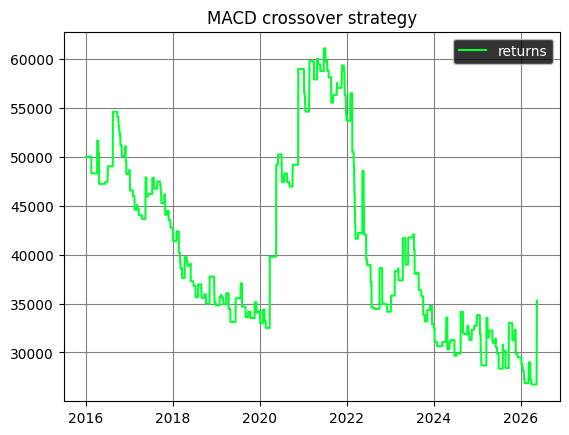

In [101]:
#Visualizing the strategy

plt.plot(google_hist.index, google_hist["Equity"], label = "returns", color = "#03ff31")
plt.style.use("dark_background")
plt.grid(color = "grey")
plt.legend()
plt.title("MACD crossover strategy")
plt.show()

All in all a succesful implementation of the popular MACD crossover strategy. As can be seen the strategy itself is awful as it managed to lose money in a 10 year span.

As for making the project I'd also call it a success, had to use AI in some instances as I was not familiar with using yfinance or some of the operations in pandas like the ewm. 
By the usage of AI, I mean asking standalone questions about some functions, did not ask it to autocomplete the whole project.

In the future I have this project to cross-reference so building something alike should be easier considering the syntax.